---
# **Analisis Data Booking Hotel Menggunakan Data Warehouse dan Business Intelligence ──★ ˙🏢 ̟ !!**


---
**Anggota Kelompok:**
- Isrina Luthfiah [2409116003]
- Nayla Camelia Indraswari [2409116009]
- Dilla Maharani [2409116023]
- Muhammad Reffi Fadillah [2409116034]

---
## **── .✦ Deskripsi Proyek**
---



Proyek ini merupakan implementasi Business Intelligence (BI) secara end-to-end yang mencakup proses:

**ETL (Extract, Transform, Load) → Data Warehouse → OLAP Analysis → Dashboard & Insight Bisnis**

Tujuan utama dari proyek ini adalah mengolah data booking hotel menjadi informasi yang dapat digunakan untuk pengambilan keputusan bisnis.

---

| Item | Detail |
|---|---|
| **Dataset** | Hotel Booking Demand (119.390 data, tahun 2015–2017) |
| **Sumber Data** | Kaggle |
| **Model Data Warehouse** | Star Schema |
| **Database Engine** | SQLite (in-memory) |
| **Tools** | Python (Pandas, Matplotlib, Seaborn), SQL |
| **Fokus Analisis** |Revenue, Cancellation Rate, Customer Segmentation, Channel Performance |

---

---
## **── .✦ Arsitektur Sistem (Architecture Overview)**
---

```
[SOURCE]            [ETL PROCESS]                 [DATA WAREHOUSE]                 [ANALYTICS]
hotel_bookings.csv  →  Data Cleaning & Transform  →  SQLite (Star Schema)         →  OLAP Queries
                                               ├─ dim_date                        →  KPI Dashboard
                                               ├─ dim_hotel                       →  Business Insights
                                               ├─ dim_customer                    →  Data Visualization
                                               ├─ dim_market
                                               ├─ dim_room
                                               └─ fact_booking


### **Source (Data Mentah)**
---



Data yang digunakan berasal dari file:

- hotel_bookings.csv

Dataset ini berisi data mentah pemesanan hotel yang masih belum terstruktur dengan baik serta memiliki beberapa nilai yang hilang (missing value).

### **ETL (Extract, Transform, Load)**
---



Pada tahap ini dilakukan proses pengolahan data, meliputi:

- Extract → mengambil data dari file CSV
- Transform → membersihkan data (data cleaning) dan menambahkan fitur baru (feature engineering)
- Load → memasukkan data yang telah diproses ke dalam database

Tools yang digunakan:

- Python (Pandas)


### **Data Warehouse**
---


Data yang telah dibersihkan kemudian disimpan dalam bentuk Star Schema menggunakan SQLite.

Struktur tabel terdiri dari:

- Fact Table
  - fact_booking

- Dimension Tables
  - dim_date
  - dim_hotel
  - dim_customer
  - dim_market
  - dim_room

Tujuan dari penggunaan Data Warehouse:

- Mempermudah proses analisis data
- Mempercepat eksekusi query

### **Analytics Layer**

---

Pada tahap ini dilakukan analisis data menggunakan SQL, yang meliputi:

- OLAP Queries
- Perhitungan Key Performance Indicators (KPI)
- Analisis bisnis

Output yang dihasilkan:

- Insight bisnis
- Visualisasi data

---
## **── .✦ Latar Belakang**
---

Industri perhotelan memiliki volume data yang besar dari aktivitas pemesanan pelanggan. Data tersebut mencakup informasi seperti waktu booking, jumlah tamu, lama menginap, harga kamar (ADR), serta status pembatalan.

Namun, data mentah tersebut belum dapat langsung digunakan untuk pengambilan keputusan bisnis karena:

- Data masih kotor (missing value, data tidak valid)
- Belum terstruktur untuk analisis
- Sulit digunakan untuk melihat pola dan tren

Oleh karena itu, diperlukan proses Business Intelligence (BI) dengan membangun Data Warehouse agar data dapat dianalisis secara efektif dan menghasilkan insight bisnis.

---
## **── .✦ Tujuan Analisis**
---

Tujuan dari project ini adalah:

- Menganalisis tren pemesanan hotel
- Mengidentifikasi faktor yang mempengaruhi pembatalan booking
- Menganalisis distribusi harga kamar (ADR)
- Mengetahui sumber pendapatan utama
- Mengidentifikasi segmen pelanggan yang paling menguntungkan

---
## **── .✦ Dataset**
---

Dataset yang digunakan berasal dari Kaggle:

"**Hotel Booking Demand**"

[https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand]

**Isi dataset:**

- Data booking hotel tahun 2015–2017
- Terdiri dari 119.390 data
- Memiliki 32 kolom

**Jenis hotel:**

- City Hotel
- Resort Hotel

**Beberapa Contoh fitur:**

- arrival_date
- lead_time
- total_nights
- adr (harga kamar)
- is_canceled
- customer_type

---
##**── .✦ Environment Setup**
---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install DuckDB untuk mendukung OLAP in-memory
!pip install duckdb --quiet

# Import library yang digunakan
import pandas as pd
import numpy as np
import sqlite3
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
from datetime import datetime

# Mengabaikan warning agar output lebih bersih
warnings.filterwarnings('ignore')

# Pengaturan tampilan dataframe
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Pengaturan style visualisasi
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FFFFFF',
    'axes.edgecolor': '#E0E0E0',
    'axes.grid': True,
    'grid.color': '#F0F0F0',
    'grid.linewidth': 0.8,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 15,
    'figure.titleweight': 'bold',
})

# Palet warna untuk visualisasi
PALETTE = ['#2E4057', '#0B4F6C', '#56A6CB', '#EFBF45', '#D96445', '#8C5E8A']

print("Environment setup selesai.")

Environment setup selesai.


Pada tahap ini dilakukan persiapan lingkungan kerja dengan menginstall dan mengimpor library yang dibutuhkan, seperti Pandas untuk pengolahan data, Matplotlib dan Seaborn untuk visualisasi, serta SQLite dan DuckDB untuk pengelolaan database dan analisis data.

---
## **── .✦ ETL (Extract, Transform, Load)**
---


### **↳ Extract — Load Raw Data**
---

Pada tahap ini dilakukan proses pengambilan data mentah dari file CSV ke dalam environment Python untuk dilakukan analisis lebih lanjut.

Data yang digunakan berasal dari file:

- hotel_bookings.csv

Proses yang dilakukan meliputi:

- Mengunggah file dataset ke Google Colab
- Membaca file menggunakan library Pandas
- Menampilkan informasi dasar dataset

In [ ]:
# ── Upload file di Colab ────────────────────────────────────────────────────
# Jalankan cell ini jika belum upload file
# from google.colab import files
# uploaded = files.upload()   # lalu pilih hotel_bookings.csv

# ── Load CSV ────────────────────────────────────────────────────────────────
RAW_PATH = '/content/drive/MyDrive/hotel_bookings.csv'   # Sesuaikan lokasi file jika berbeda

df_raw = pd.read_csv(RAW_PATH)

print(f'Jumlah data      : {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
print(f'Penggunaan memori: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'Rentang tahun    : {df_raw.arrival_date_year.min()} – {df_raw.arrival_date_year.max()}')
print()
print('── Missing values ──')
miss = df_raw.isnull().sum()
print(miss[miss > 0])

df_raw.head(3)

Jumlah data      : 119,390 baris × 32 kolom
Penggunaan memori: 98.5 MB
Rentang tahun    : 2015 – 2017

── Missing values ──
children         4
country        488
agent        16340
company     112593
dtype: int64


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02


#### **Proses yang dilakukan**
---

##### **1. Load Data**


Data dibaca menggunakan Pandas dan disimpan dalam bentuk DataFrame.

##### **2. Eksplorasi Awal Data**


Untuk memahami struktur data, dilakukan:

- Melihat jumlah baris dan kolom
- Mengecek tipe data
- Menampilkan beberapa data awal
- Mengecek nilai yang hilang (missing values)

#### **Hasil**
---

Berdasarkan hasil eksplorasi awal terhadap dataset, diperoleh beberapa informasi sebagai berikut:

- Dataset terdiri dari 119.390 baris dan 32 kolom
- Data mencakup periode waktu dari tahun 2015 hingga 2017
- Ditemukan beberapa missing value pada beberapa kolom, antara lain:
  - children
  - country
  - agent
  - company

Berdasarkan kondisi tersebut, dapat disimpulkan bahwa data masih belum bersih dan memerlukan proses data cleaning pada tahap selanjutnya agar dapat digunakan untuk analisis lebih lanjut.


### **↳ Transform — Data Cleaning & Feature Engineering**
---

Pada tahap transformasi, data mentah dibersihkan dan disiapkan agar dapat digunakan untuk proses analisis dan pemuatan ke data warehouse.

In [ ]:
df = df_raw.copy()

# ── 2.1  Menangani missing values ───────────────────────────────────────────
df['children']  = df['children'].fillna(0).astype(int)
df['country']   = df['country'].fillna('Unknown')
df['agent']     = df['agent'].fillna(0)
df['company']   = df['company'].fillna(0)

# ── 2.2  Menghapus data tidak valid ─────────────────────────────────────────
# Nilai ADR negatif tidak masuk akal secara bisnis
before = len(df)
df = df[df['adr'] >= 0]
df = df[(df['adults'] + df['children'] + df['babies']) > 0]   # harus ada tamu
print(f'Menghapus {before - len(df):,} baris tidak valid → {len(df):,} data bersih')

# ── 2.3  Menambahkan kolom turunan ──────────────────────────────────────────
MONTH_ORDER = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d', errors='coerce'
)

df['total_nights']    = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests']    = df['adults'] + df['children'] + df['babies']
df['total_revenue']   = df['adr'] * df['total_nights']
df['month_num']       = pd.Categorical(df['arrival_date_month'],
                                        categories=MONTH_ORDER, ordered=True)
df['quarter']         = df['arrival_date'].dt.quarter.map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})
df['is_family']       = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)
df['room_upgraded']   = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

# booking_id sebagai surrogate key
df = df.reset_index(drop=True)
df.insert(0, 'booking_id', range(1, len(df) + 1))

print('\n── Kolom turunan berhasil ditambahkan ──')
print(df[['booking_id','arrival_date','total_nights','total_revenue','quarter']].head(3))
print(f'\nTransformasi selesai: {len(df):,} data siap dimuat')

Menghapus 181 baris tidak valid → 119,209 data bersih

── Kolom turunan berhasil ditambahkan ──
   booking_id arrival_date  total_nights  total_revenue quarter
0           1   2015-07-01             0           0.00      Q3
1           2   2015-07-01             0           0.00      Q3
2           3   2015-07-01             1          75.00      Q3

Transformasi selesai: 119,209 data siap dimuat


#### **Proses yang dilakukan**
---

##### **1. Penanganan missing value**

Beberapa nilai kosong pada dataset ditangani dengan cara:

- children diisi dengan nilai 0
- country diisi dengan "Unknown"
- agent dan company diisi dengan nilai 0

Langkah ini dilakukan agar data tidak menimbulkan error pada proses selanjutnya.

##### **2. Penghapusan data tidak valid**

Setelah itu dilakukan penghapusan data yang tidak valid, yaitu:

- data dengan nilai ADR negatif
- data booking tanpa tamu

Hal ini bertujuan agar data yang digunakan benar-benar sesuai dengan kondisi bisnis yang wajar.

##### **3. Penambahan kolom turunan**

Untuk mendukung analisis, ditambahkan beberapa kolom baru, yaitu:

- arrival_date, untuk membentuk tanggal kedatangan lengkap
- total_nights, untuk menghitung total lama menginap
- total_guests, untuk menghitung jumlah tamu
- total_revenue, untuk menghitung estimasi pendapatan
- quarter, untuk mengelompokkan data berdasarkan kuartal
- is_family, untuk menandai booking keluarga
- room_upgraded, untuk mengetahui apakah terjadi perubahan tipe kamar

##### **4. Pembuatan surrogate key**

Penambahan booking_id sebagai identitas unik untuk setiap booking yang nantinya digunakan pada tabel fakta.

#### **Hasil**
---

Berdasarkan proses transformasi yang dilakukan:

- missing value utama telah ditangani
- data yang tidak valid telah dihapus
- dataset menjadi lebih bersih dan siap digunakan
- ditambahkan beberapa kolom baru yang mendukung analisis bisnis


### **↳ Load — Build Star Schema Data Warehouse**
---

```
                  ┌──────────────┐
                  │   dim_date   │
                  └──────┬───────┘
                         │
  ┌──────────────┐       │       ┌──────────────┐
  │  dim_hotel   ├───────┼───────┤ dim_customer │
  └──────────────┘       │       └──────────────┘
                         │
                  ┌──────┴───────┐
                  │ fact_booking │
                  └──────┬───────┘
                         │
  ┌──────────────┐       │       ┌──────────────┐
  │  dim_market  ├───────┼───────┤  dim_room    │
  └──────────────┘               └──────────────┘
```

Pada tahap ini, data hasil transformasi dimuat ke dalam Data Warehouse menggunakan SQLite dengan model Star Schema. Model ini dipilih karena memudahkan proses analisis dan mempercepat query.

In [ ]:
# ── Inisialisasi SQLite DW ──────────────────────────────────────────────────
conn = sqlite3.connect(':memory:')   # in-memory; ganti path jika ingin disimpan permanen
cur  = conn.cursor()

# ═══════════════════════════════════════════════════════════════════════
# DIM_DATE
# ═══════════════════════════════════════════════════════════════════════
cur.execute('''
CREATE TABLE IF NOT EXISTS dim_date (
    date_key       INTEGER PRIMARY KEY,   -- YYYYMMDD
    full_date      TEXT,
    year           INTEGER,
    quarter        TEXT,
    month_num      INTEGER,
    month_name     TEXT,
    week_number    INTEGER,
    day_of_month   INTEGER
)''')

dim_date = df[['arrival_date','arrival_date_year','quarter',
               'arrival_date_month','arrival_date_week_number',
               'arrival_date_day_of_month']].drop_duplicates(subset='arrival_date').copy()
dim_date = dim_date.dropna(subset=['arrival_date'])
dim_date['date_key']   = dim_date['arrival_date'].dt.strftime('%Y%m%d').astype(int)
dim_date['full_date']  = dim_date['arrival_date'].dt.strftime('%Y-%m-%d')
dim_date['month_num']  = dim_date['arrival_date'].dt.month
dim_date = dim_date.rename(columns={
    'arrival_date_year'         : 'year',
    'arrival_date_month'        : 'month_name',
    'arrival_date_week_number'  : 'week_number',
    'arrival_date_day_of_month' : 'day_of_month'
})
dim_date[['date_key','full_date','year','quarter','month_num',
          'month_name','week_number','day_of_month']].to_sql(
    'dim_date', conn, if_exists='replace', index=False)

# ═══════════════════════════════════════════════════════════════════════
# DIM_HOTEL
# ═══════════════════════════════════════════════════════════════════════
cur.execute('''
CREATE TABLE IF NOT EXISTS dim_hotel (
    hotel_key  INTEGER PRIMARY KEY AUTOINCREMENT,
    hotel_name TEXT UNIQUE
)''')

dim_hotel = pd.DataFrame({'hotel_name': df['hotel'].unique()})
dim_hotel.insert(0, 'hotel_key', range(1, len(dim_hotel)+1))
dim_hotel.to_sql('dim_hotel', conn, if_exists='replace', index=False)

# ═══════════════════════════════════════════════════════════════════════
# DIM_CUSTOMER
# ═══════════════════════════════════════════════════════════════════════
cur.execute('''
CREATE TABLE IF NOT EXISTS dim_customer (
    customer_key       INTEGER PRIMARY KEY AUTOINCREMENT,
    customer_type      TEXT,
    country            TEXT,
    is_repeated_guest  INTEGER,
    is_family          INTEGER
)''')

dim_customer = df[['customer_type','country','is_repeated_guest','is_family']] \
    .drop_duplicates().reset_index(drop=True).copy()
dim_customer.insert(0, 'customer_key', range(1, len(dim_customer)+1))
dim_customer.to_sql('dim_customer', conn, if_exists='replace', index=False)

# ═══════════════════════════════════════════════════════════════════════
# DIM_MARKET
# ═══════════════════════════════════════════════════════════════════════
cur.execute('''
CREATE TABLE IF NOT EXISTS dim_market (
    market_key            INTEGER PRIMARY KEY AUTOINCREMENT,
    market_segment        TEXT,
    distribution_channel  TEXT,
    deposit_type          TEXT
)''')

dim_market = df[['market_segment','distribution_channel','deposit_type']] \
    .drop_duplicates().reset_index(drop=True).copy()
dim_market.insert(0, 'market_key', range(1, len(dim_market)+1))
dim_market.to_sql('dim_market', conn, if_exists='replace', index=False)

# ═══════════════════════════════════════════════════════════════════════
# DIM_ROOM
# ═══════════════════════════════════════════════════════════════════════
cur.execute('''
CREATE TABLE IF NOT EXISTS dim_room (
    room_key            INTEGER PRIMARY KEY AUTOINCREMENT,
    reserved_room_type  TEXT,
    assigned_room_type  TEXT,
    meal                TEXT
)''')

dim_room = df[['reserved_room_type','assigned_room_type','meal']] \
    .drop_duplicates().reset_index(drop=True).copy()
dim_room.insert(0, 'room_key', range(1, len(dim_room)+1))
dim_room.to_sql('dim_room', conn, if_exists='replace', index=False)

print('✅ Semua tabel dimensi berhasil dimuat.')

✅ Semua tabel dimensi berhasil dimuat.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# FACT_BOOKING — menghubungkan surrogate key dari seluruh tabel dimensi
# ═══════════════════════════════════════════════════════════════════════

# Mengambil surrogate key dari tabel dimensi
dh = pd.read_sql('SELECT * FROM dim_hotel',    conn)
dc = pd.read_sql('SELECT * FROM dim_customer', conn)
dm = pd.read_sql('SELECT * FROM dim_market',   conn)
dr = pd.read_sql('SELECT * FROM dim_room',     conn)

fact = df.copy()

# date_key
fact['date_key'] = fact['arrival_date'].dt.strftime('%Y%m%d').astype('Int64')

# hotel_key
fact = fact.merge(dh[['hotel_key','hotel_name']].rename(columns={'hotel_name':'hotel'}),
                  on='hotel', how='left')

# customer_key
fact = fact.merge(dc, on=['customer_type','country','is_repeated_guest','is_family'], how='left')

# market_key
fact = fact.merge(dm, on=['market_segment','distribution_channel','deposit_type'], how='left')

# room_key
fact = fact.merge(dr, on=['reserved_room_type','assigned_room_type','meal'], how='left')

# Kolom tabel fakta
FACT_COLS = [
    'booking_id', 'date_key', 'hotel_key', 'customer_key', 'market_key', 'room_key',
    'is_canceled', 'lead_time', 'total_nights', 'total_guests',
    'adr', 'total_revenue', 'booking_changes', 'days_in_waiting_list',
    'required_car_parking_spaces', 'total_of_special_requests', 'room_upgraded',
    'reservation_status'
]

fact_booking = fact[FACT_COLS].copy()
fact_booking.to_sql('fact_booking', conn, if_exists='replace', index=False)

# Verifikasi
row_count = pd.read_sql('SELECT COUNT(*) as n FROM fact_booking', conn).iloc[0,0]
print(f'✅ fact_booking berhasil dimuat: {row_count:,} baris')
print()

# Ringkasan data warehouse
tables = ['dim_date','dim_hotel','dim_customer','dim_market','dim_room','fact_booking']
print('── Ringkasan Data Warehouse ──────────────────')
for t in tables:
    n = pd.read_sql(f'SELECT COUNT(*) as n FROM {t}', conn).iloc[0,0]
    print(f'  {t:<22} {n:>8,} baris')

✅ fact_booking berhasil dimuat: 119,209 baris

── Ringkasan Data Warehouse ──────────────────
  dim_date                    793 baris
  dim_hotel                     2 baris
  dim_customer                649 baris
  dim_market                   44 baris
  dim_room                    187 baris
  fact_booking            119,209 baris


#### **Proses yang dilakukan**
---

##### **1. Inisialisasi Database**

Database dibuat menggunakan SQLite. Pada implementasi ini, database dijalankan secara in-memory, sehingga proses pemuatan dan analisis dapat dilakukan dengan lebih cepat.

##### **2. Pembuatan Tabel Dimensi**

Beberapa tabel dimensi dibuat untuk menyimpan data deskriptif, yaitu:

- dim_date → menyimpan informasi waktu (tanggal, bulan, kuartal)
- dim_hotel → menyimpan jenis hotel
- dim_customer → menyimpan informasi pelanggan
- dim_market → menyimpan informasi segmen pasar dan channel distribusi
- dim_room → menyimpan informasi tipe kamar dan layanan (meal)

##### **3. Pengisian Tabel Dimensi**

Setelah tabel dibuat, data unik dari hasil transformasi dimasukkan ke masing-masing tabel dimensi. Proses ini bertujuan untuk:

- Menghindari redundansi data
- Menyusun data secara terstruktur
- Mempermudah proses join pada tahap selanjutnya

##### **4. Pembuatan Tabel Fakta (fact_booking)**

Setelah tabel dimensi selesai, dilakukan pembuatan tabel fakta fact_booking sebagai pusat dari star schema.

Proses yang dilakukan meliputi:

- Mengambil data dari tabel dimensi
- Menambahkan date_key sebagai representasi waktu
- Melakukan join antara data hasil transformasi dengan tabel dimensi untuk mendapatkan:
  - hotel_key
  - customer_key
  - market_key
  - room_key
- Menyusun kolom-kolom utama yang akan digunakan dalam analisis

Tabel fakta ini berisi data transaksi utama seperti:

- jumlah tamu
- lama menginap
- pendapatan (revenue)
- status booking

#### **Hasil**
---

##### **Hasil Pembuatan Tabel Dimensi**

Berdasarkan proses load yang dilakukan, seluruh tabel dimensi berhasil dibuat dan dimuat ke dalam database. Tabel-tabel tersebut berisi data unik yang akan digunakan sebagai referensi pada tabel fakta.

Tabel dimensi yang berhasil dibuat meliputi:

- dim_date
- dim_hotel
- dim_customer
- dim_market
- dim_room


##### **Hasil Pembuatan Tabel Fakta**

Tabel fact_booking berhasil dibuat dengan jumlah 119.209 baris. Tabel ini berisi data transaksi booking yang telah terhubung dengan seluruh tabel dimensi melalui surrogate key.

Selain itu, diperoleh ringkasan jumlah data pada masing-masing tabel sebagai berikut:

- dim_date : 793 baris
- dim_hotel : 2 baris
- dim_customer : 649 baris
- dim_market : 44 baris
- dim_room : 187 baris
- fact_booking : 119.209 baris

#### **Kesimpulan**
---

Dengan terbentuknya tabel dimensi dan tabel fakta, struktur Star Schema telah lengkap. Data warehouse yang dihasilkan siap digunakan untuk proses analisis data (OLAP), visualisasi, dan pengambilan insight bisnis.

---
## **── .✦ Analytics – OLAP & Analisis Data**
---

### **↳ OLAP Queries – Business Questions**
---

Pada tahap ini dilakukan analisis data menggunakan query SQL pada data warehouse untuk menjawab beberapa pertanyaan bisnis utama. Query yang digunakan berfokus pada:

1. Analisis revenue hotel berdasarkan waktu
2. Analisis pembatalan booking berdasarkan segmen pasar dan lead time
3. Analisis segmentasi pelanggan
4. Analisis negara dengan kontribusi revenue tertinggi

#### **Q1. Analisis Revenue Hotel**
---

In [ ]:
# ============================================================================
# Q1. Analisis revenue hotel per periode waktu
# ============================================================================
q_rev = '''
SELECT
    h.hotel_name,
    d.year,
    d.quarter,
    d.month_name,
    d.month_num,
    SUM(f.total_revenue) AS total_revenue,
    COUNT(f.booking_id) AS total_bookings,
    SUM(CASE WHEN f.is_canceled = 0 THEN f.total_revenue ELSE 0 END) AS confirmed_revenue,
    AVG(f.adr) AS avg_daily_rate,
    AVG(f.total_nights) AS avg_length_of_stay
FROM fact_booking f
JOIN dim_hotel h ON f.hotel_key = h.hotel_key
JOIN dim_date d ON f.date_key = d.date_key
WHERE f.total_revenue > 0
GROUP BY h.hotel_name, d.year, d.quarter, d.month_name, d.month_num
ORDER BY h.hotel_name, d.year, d.month_num
'''
df_rev = pd.read_sql(q_rev, conn)
print('Revenue Query → shape:', df_rev.shape)
df_rev.head(6)

Revenue Query → shape: (52, 10)


,hotel_name,year,quarter,month_name,month_num,total_revenue,total_bookings,confirmed_revenue,avg_daily_rate,avg_length_of_stay
0,City Hotel,2015,Q3,July,7,"261,597.86",1356,"79,645.69",71.98,2.71
1,City Hotel,2015,Q3,August,8,"522,375.86",2405,"285,197.49",80.15,2.73
2,City Hotel,2015,Q3,September,9,"1,028,107.17",3451,"588,544.97",103.35,2.75
3,City Hotel,2015,Q4,October,10,"804,850.12",3305,"521,369.65",91.58,2.65
4,City Hotel,2015,Q4,November,11,"268,243.96",1200,"191,210.34",75.68,2.96
5,City Hotel,2015,Q4,December,12,"406,515.08",1573,"228,337.40",85.28,3.04


Query ini digunakan untuk menganalisis performa pendapatan hotel berdasarkan dimensi waktu dan jenis hotel. Analisis dilakukan dengan mengelompokkan data berdasarkan tahun, kuartal, dan bulan, sehingga dapat terlihat pola perubahan revenue dari waktu ke waktu. Selain menghitung total revenue, query ini juga menghasilkan informasi tambahan seperti jumlah booking, confirmed revenue, rata-rata harga kamar (ADR), serta rata-rata lama menginap pelanggan. Dengan analisis ini, dapat diketahui tren pendapatan hotel dan periode dengan performa terbaik.

#### **Q2. Analisis Cancellation**
---

In [ ]:
# ============================================================================
# Q2. Analisis pembatalan booking berdasarkan market segment dan lead time
# ============================================================================
q_cancel = '''
SELECT
    h.hotel_name,
    m.market_segment,
    m.distribution_channel,
    m.deposit_type,
    CASE
        WHEN f.lead_time <= 7   THEN '0-7 days'
        WHEN f.lead_time <= 30  THEN '8-30 days'
        WHEN f.lead_time <= 90  THEN '31-90 days'
        WHEN f.lead_time <= 180 THEN '91-180 days'
        ELSE '180+ days'
    END AS lead_time_bucket,
    COUNT(*) AS total_bookings,
    SUM(f.is_canceled) AS total_canceled,
    ROUND(100.0 * SUM(f.is_canceled) / COUNT(*), 2) AS cancel_rate_pct,
    ROUND(AVG(f.lead_time), 1) AS avg_lead_time
FROM fact_booking f
JOIN dim_hotel h ON f.hotel_key = h.hotel_key
JOIN dim_market m ON f.market_key = m.market_key
GROUP BY h.hotel_name, m.market_segment, m.distribution_channel,
         m.deposit_type, lead_time_bucket
ORDER BY cancel_rate_pct DESC
'''
df_cancel = pd.read_sql(q_cancel, conn)
print('Cancellation Query → shape:', df_cancel.shape)
df_cancel.head(6)

Cancellation Query → shape: (256, 9)


,hotel_name,market_segment,distribution_channel,deposit_type,lead_time_bucket,total_bookings,total_canceled,cancel_rate_pct,avg_lead_time
0,City Hotel,Complementary,Corporate,No Deposit,31-90 days,2,2,100.00,59.00
1,City Hotel,Corporate,Corporate,Refundable,91-180 days,1,1,100.00,113.00
2,City Hotel,Corporate,TA/TO,Non Refund,180+ days,2,2,100.00,212.00
3,City Hotel,Corporate,TA/TO,Non Refund,91-180 days,71,71,100.00,131.60
4,City Hotel,Direct,Direct,Non Refund,8-30 days,6,6,100.00,16.80
5,City Hotel,Direct,Direct,Non Refund,91-180 days,10,10,100.00,165.20


Query ini bertujuan untuk menganalisis tingkat pembatalan booking berdasarkan berbagai faktor, seperti jenis hotel, market segment, distribution channel, deposit type, serta kelompok lead time. Data lead time dikelompokkan ke dalam beberapa kategori untuk mempermudah analisis pola pembatalan. Selain jumlah booking, query ini juga menghitung total pembatalan, persentase cancellation rate, dan rata-rata lead time. Hasil analisis ini digunakan untuk memahami faktor-faktor yang memengaruhi pembatalan booking.

#### **Q3. Analisis Segmentasi Pelanggan**
---

In [ ]:
# ============================================================================
# Q3. Analisis segmentasi pelanggan: nilai, loyalitas, dan upgrade kamar
# ============================================================================
q_seg = '''
SELECT
    c.customer_type,
    c.is_repeated_guest,
    c.is_family,
    h.hotel_name,
    COUNT(f.booking_id) AS bookings,
    ROUND(AVG(f.total_revenue), 2) AS avg_revenue,
    ROUND(AVG(f.adr), 2) AS avg_adr,
    ROUND(AVG(f.total_nights), 1) AS avg_nights,
    ROUND(AVG(f.total_of_special_requests), 2) AS avg_special_req,
    ROUND(100.0 * SUM(f.room_upgraded) / COUNT(*), 1) AS upgrade_rate_pct,
    ROUND(100.0 * SUM(f.is_canceled) / COUNT(*), 1) AS cancel_rate_pct
FROM fact_booking f
JOIN dim_customer c ON f.customer_key = c.customer_key
JOIN dim_hotel h ON f.hotel_key = h.hotel_key
GROUP BY c.customer_type, c.is_repeated_guest, c.is_family, h.hotel_name
ORDER BY avg_revenue DESC
'''
df_seg = pd.read_sql(q_seg, conn)
print('Segmentation Query → shape:', df_seg.shape)
df_seg.head(8)

Segmentation Query → shape: (30, 11)


,customer_type,is_repeated_guest,is_family,hotel_name,bookings,avg_revenue,avg_adr,avg_nights,avg_special_req,upgrade_rate_pct,cancel_rate_pct
0,Transient,0,1,Resort Hotel,3501,816.92,165.24,4.80,0.82,9.40,38.60
1,Contract,0,1,Resort Hotel,64,694.13,92.63,7.30,1.20,25.00,12.50
2,Contract,0,0,Resort Hotel,1693,679.37,78.80,8.60,0.46,10.20,8.60
3,Contract,1,0,Resort Hotel,19,614.13,62.63,8.50,1.21,15.80,21.10
4,Transient-Party,0,1,Resort Hotel,301,612.52,134.78,4.40,1.09,17.90,11.60
5,Group,0,1,Resort Hotel,11,600.86,162.60,3.40,1.09,9.10,9.10
6,Group,1,1,Resort Hotel,6,537.50,107.71,3.20,1.00,33.30,0.00
7,Transient,0,1,City Hotel,4878,508.72,152.81,3.40,0.96,15.10,36.20


Query ini digunakan untuk mengelompokkan pelanggan berdasarkan karakteristik tertentu, yaitu tipe pelanggan, status sebagai pelanggan tetap (repeated guest), kategori keluarga, serta jenis hotel yang dipilih. Dari hasil pengelompokan tersebut, dihitung berbagai metrik seperti jumlah booking, rata-rata revenue, rata-rata harga kamar (ADR), rata-rata lama menginap, jumlah permintaan khusus, tingkat upgrade kamar, serta tingkat pembatalan. Analisis ini bertujuan untuk mengidentifikasi segmen pelanggan yang paling bernilai dan memiliki tingkat loyalitas tinggi.

#### **Q4. Analisis Geografis Revenue**
---

In [ ]:
# ============================================================================
# Q4. Top 15 negara berdasarkan confirmed revenue
# ============================================================================
q_geo = '''
SELECT
    c.country,
    COUNT(f.booking_id) AS bookings,
    SUM(CASE WHEN f.is_canceled = 0 THEN f.total_revenue ELSE 0 END) AS confirmed_revenue,
    ROUND(AVG(f.adr), 2) AS avg_adr,
    ROUND(100.0 * SUM(f.is_canceled) / COUNT(*), 1) AS cancel_rate_pct
FROM fact_booking f
JOIN dim_customer c ON f.customer_key = c.customer_key
WHERE c.country != 'Unknown'
GROUP BY c.country
ORDER BY confirmed_revenue DESC
LIMIT 15
'''
df_geo = pd.read_sql(q_geo, conn)
df_geo

,country,bookings,confirmed_revenue,avg_adr,cancel_rate_pct
0,PRT,48483,"5,540,431.72",92.23,56.70
1,GBR,12119,"4,110,896.61",96.09,20.20
2,FRA,10401,"3,098,418.27",109.76,18.60
3,ESP,8560,"2,246,305.29",117.09,25.40
4,DEU,7285,"2,068,219.65",104.43,16.70
5,IRL,3374,"1,240,002.35",98.22,24.70
6,ITA,3761,"866,439.42",114.10,35.40
7,BEL,2342,"759,145.06",113.85,20.20
8,NLD,2103,"631,636.11",108.14,18.40
9,CHE,1726,"547,591.16",121.99,24.80


Query ini digunakan untuk menganalisis kontribusi pendapatan berdasarkan negara asal pelanggan. Analisis difokuskan pada confirmed revenue untuk mendapatkan gambaran pendapatan yang benar-benar terealisasi. Selain itu, ditampilkan juga jumlah booking, rata-rata harga kamar (ADR), serta tingkat pembatalan untuk masing-masing negara. Hasil dari analisis ini dapat digunakan untuk mengetahui negara yang paling berkontribusi terhadap pendapatan hotel dan sebagai dasar dalam menentukan strategi pemasaran.

### **↳ Executive KPI Summary**
---

Pada bagian ini dilakukan perhitungan Key Performance Indicators (KPI) untuk memberikan gambaran umum mengenai performa bisnis hotel selama periode 2015–2017. KPI digunakan sebagai ringkasan utama sebelum dilakukan analisis yang lebih mendalam.

Beberapa indikator yang dihitung meliputi jumlah total booking, jumlah booking yang terkonfirmasi, tingkat pembatalan, total confirmed revenue, rata-rata harga kamar (ADR), rata-rata lama menginap, rata-rata jumlah tamu per booking, serta tingkat upgrade kamar. Dengan adanya KPI ini, kondisi bisnis hotel dapat dipahami secara cepat melalui indikator-indikator utama yang paling relevan.

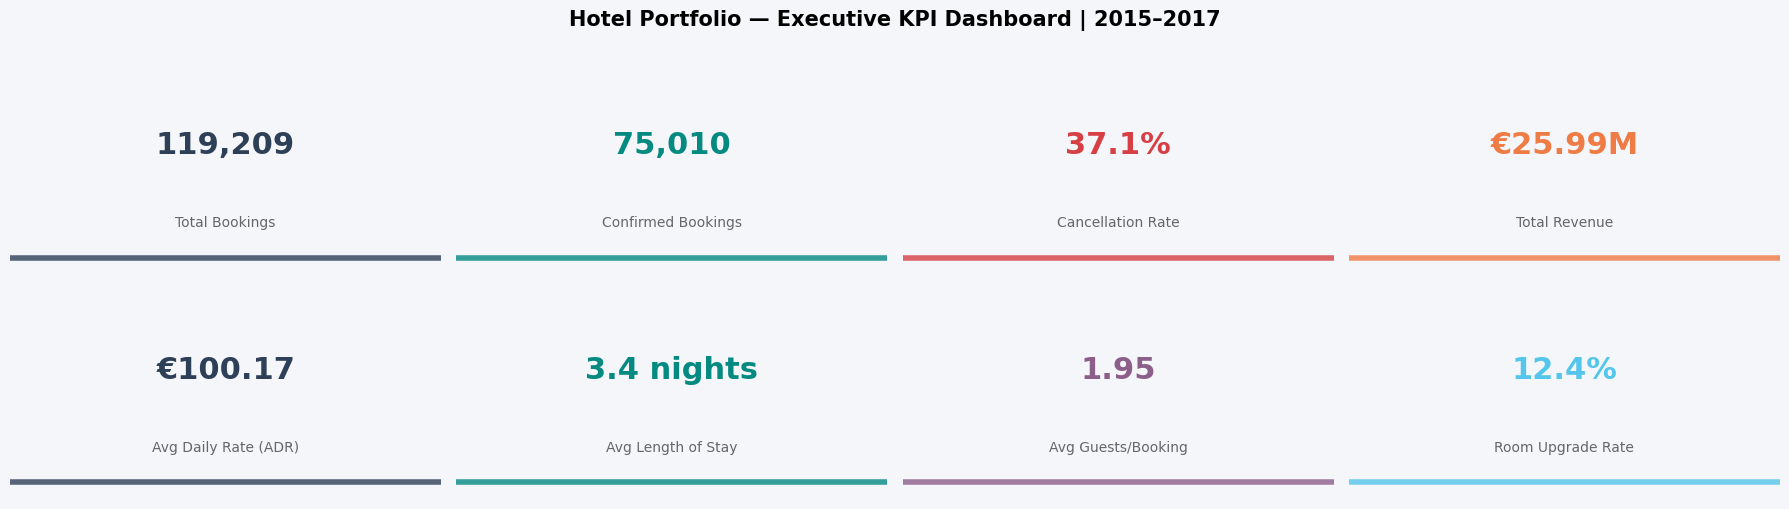

Dashboard KPI berhasil disimpan.


In [ ]:
# ============================================================================
# KPI Summary
# ============================================================================
q_kpi = '''
SELECT
    COUNT(*) AS total_bookings,
    SUM(CASE WHEN is_canceled = 0 THEN 1 ELSE 0 END) AS confirmed_bookings,
    ROUND(100.0 * SUM(is_canceled) / COUNT(*), 2) AS overall_cancel_rate,
    ROUND(SUM(CASE WHEN is_canceled = 0 THEN total_revenue ELSE 0 END), 2) AS total_confirmed_revenue,
    ROUND(AVG(CASE WHEN is_canceled = 0 THEN adr END), 2) AS avg_adr,
    ROUND(AVG(CASE WHEN is_canceled = 0 THEN total_nights END), 2) AS avg_length_of_stay,
    ROUND(AVG(CASE WHEN is_canceled = 0 THEN total_guests END), 2) AS avg_guests_per_booking,
    SUM(room_upgraded) AS total_upgrades,
    ROUND(100.0 * SUM(room_upgraded) / COUNT(*), 2) AS upgrade_rate
FROM fact_booking
'''
kpi = pd.read_sql(q_kpi, conn).iloc[0]

# ============================================================================
# Visualisasi KPI dalam bentuk kartu dashboard
# ============================================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 5))
fig.suptitle('Hotel Portfolio — Executive KPI Dashboard | 2015–2017', y=1.01)
fig.patch.set_facecolor('#F4F6F9')

kpis = [
    ('Total Bookings',       f"{int(kpi['total_bookings']):,}",              '#2E4057'),
    ('Confirmed Bookings',   f"{int(kpi['confirmed_bookings']):,}",          '#048A81'),
    ('Cancellation Rate',    f"{kpi['overall_cancel_rate']:.1f}%",           '#D64045'),
    ('Total Revenue',        f"€{kpi['total_confirmed_revenue']/1e6:.2f}M",  '#EF7B45'),
    ('Avg Daily Rate (ADR)', f"€{kpi['avg_adr']:.2f}",                       '#2E4057'),
    ('Avg Length of Stay',   f"{kpi['avg_length_of_stay']:.1f} nights",      '#048A81'),
    ('Avg Guests/Booking',   f"{kpi['avg_guests_per_booking']:.2f}",         '#8C5E8A'),
    ('Room Upgrade Rate',    f"{kpi['upgrade_rate']:.1f}%",                  '#54C6EB'),
]

for ax, (label, value, color) in zip(axes.flat, kpis):
    ax.set_facecolor('#FFFFFF')
    ax.text(0.5, 0.62, value, ha='center', va='center', fontsize=22,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=10,
            color='#666666', transform=ax.transAxes)
    ax.axhline(0.08, color=color, linewidth=4, alpha=0.8)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig('kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print('Dashboard KPI berhasil disimpan.')

Berdasarkan hasil perhitungan KPI, diperoleh gambaran umum performa bisnis hotel selama periode 2015–2017. Dashboard KPI menunjukkan total jumlah booking, jumlah booking yang terkonfirmasi, tingkat pembatalan, total revenue yang berhasil direalisasikan, rata-rata harga kamar, rata-rata lama menginap, jumlah tamu per booking, serta tingkat upgrade kamar.

Melalui KPI ini, dapat diketahui kondisi bisnis hotel secara ringkas sebelum dilakukan analisis yang lebih mendalam pada tahap berikutnya.

### **↳ Business Analytics — Deep Dive**
---

Pada tahap ini dilakukan analisis lebih mendalam (deep dive analysis) berdasarkan hasil OLAP dan KPI sebelumnya. Analisis ini bertujuan untuk menggali pola, tren, serta hubungan antar variabel yang dapat memberikan pemahaman lebih dalam terhadap performa bisnis hotel.

Visualisasi digunakan untuk memperjelas hasil analisis sehingga lebih mudah diinterpretasikan.

#### **1. Analisis Tren Revenue Bulanan**
---

Analisis ini bertujuan untuk melihat pola perubahan pendapatan hotel dari waktu ke waktu berdasarkan bulan dan tahun. Data yang digunakan adalah confirmed revenue, sehingga mencerminkan pendapatan yang benar-benar terealisasi.

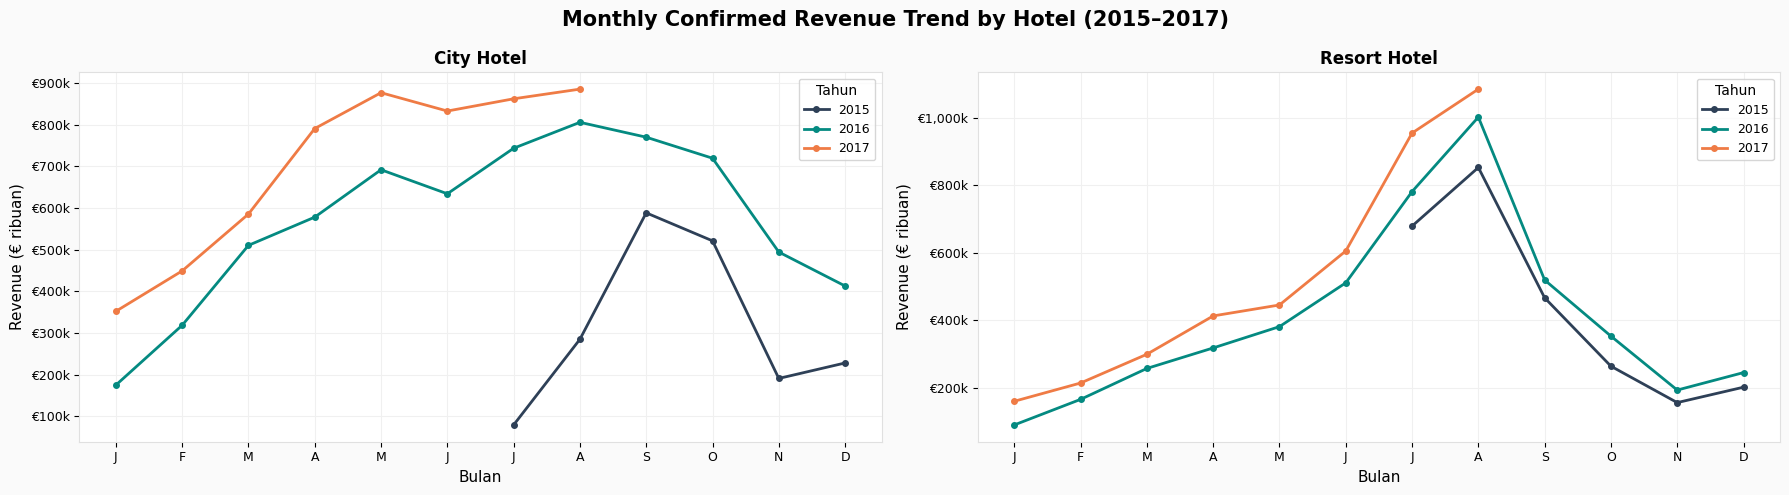

In [ ]:
# ============================================================================
# 1 Tren Revenue Bulanan per Hotel
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=False)
fig.suptitle('Monthly Confirmed Revenue Trend by Hotel (2015–2017)')

hotels = df_rev['hotel_name'].unique()
years = sorted(df_rev['year'].unique())
colors = ['#2E4057', '#048A81', '#EF7B45']

for ax, hotel in zip(axes, hotels):
    subset = df_rev[df_rev['hotel_name'] == hotel].copy()
    for yr, color in zip(years, colors):
        data = subset[subset['year'] == yr].sort_values('month_num')
        if len(data):
            ax.plot(
                data['month_num'],
                data['confirmed_revenue'] / 1e3,
                marker='o',
                markersize=4,
                linewidth=2,
                color=color,
                label=str(yr)
            )

    ax.set_title(hotel, fontsize=12)
    ax.set_xlabel('Bulan')
    ax.set_ylabel('Revenue (€ ribuan)')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'€{x:,.0f}k'))
    ax.legend(title='Tahun')

plt.tight_layout()
plt.savefig('revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

Terlihat bahwa revenue mengalami fluktuasi sepanjang tahun dengan pola tertentu yang cenderung berulang setiap tahun. Pada periode tertentu, khususnya pertengahan tahun, terjadi peningkatan revenue yang cukup signifikan, yang mengindikasikan adanya peak season. Selain itu, terdapat perbedaan performa antara jenis hotel, di mana salah satu hotel menunjukkan kontribusi revenue yang lebih tinggi secara konsisten.

#### **2. Analisis Cancellation**
---

Analisis ini dilakukan untuk memahami pola pembatalan booking berdasarkan:

- market segment
- deposit type
- lead time

Visualisasi heatmap digunakan untuk melihat kombinasi faktor yang memiliki tingkat pembatalan tinggi, sedangkan grafik batang digunakan untuk melihat hubungan antara lead time dan cancellation rate.

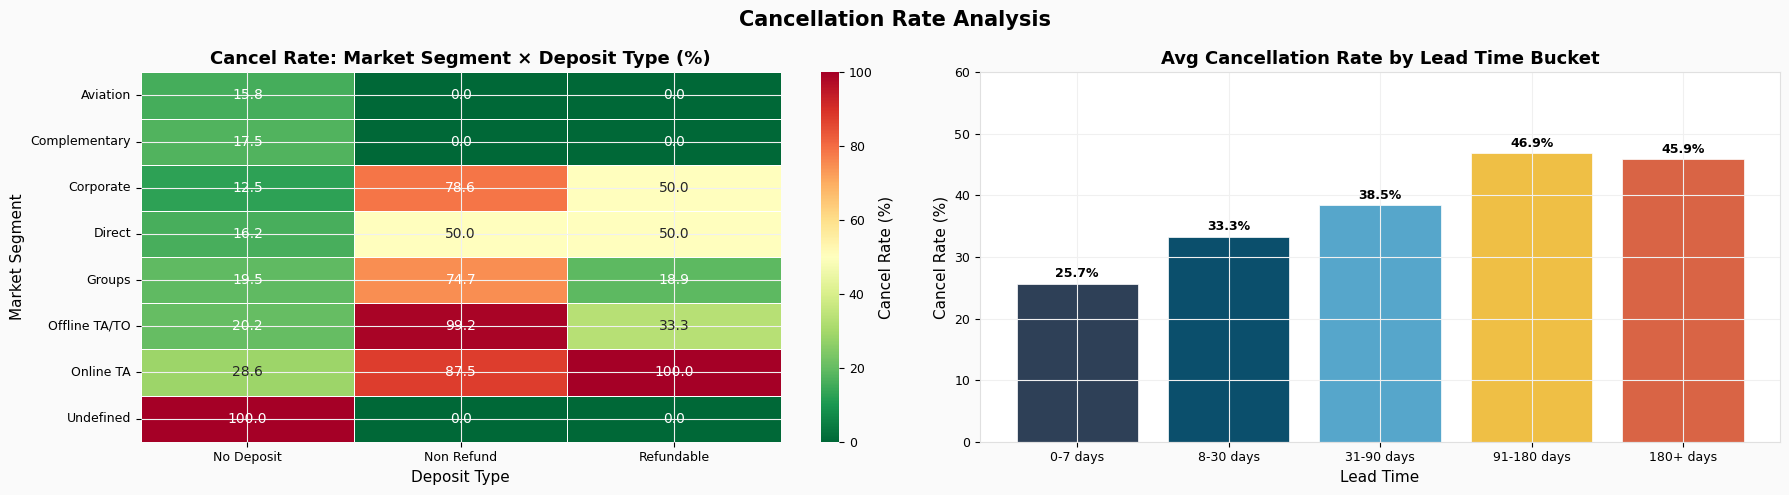

In [ ]:
# ============================================================================
# 2 Analisis Cancellation berdasarkan Market Segment dan Deposit Type
# ============================================================================
pivot_cancel = df_cancel.groupby(['market_segment', 'deposit_type'])['cancel_rate_pct'] \
    .mean().unstack(fill_value=0).round(1)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Cancellation Rate Analysis')

# Heatmap cancellation rate
sns.heatmap(
    pivot_cancel,
    ax=axes[0],
    cmap='RdYlGn_r',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Cancel Rate (%)'},
    vmin=0,
    vmax=100
)
axes[0].set_title('Cancel Rate: Market Segment × Deposit Type (%)')
axes[0].set_xlabel('Deposit Type')
axes[0].set_ylabel('Market Segment')

# Rata-rata cancellation rate berdasarkan kelompok lead time
lt_data = df_cancel.groupby('lead_time_bucket').agg(
    cancel_rate=('cancel_rate_pct', 'mean'),
    bookings=('total_bookings', 'sum')
).reset_index()

ORDER_LT = ['0-7 days', '8-30 days', '31-90 days', '91-180 days', '180+ days']
lt_data['lead_time_bucket'] = pd.Categorical(
    lt_data['lead_time_bucket'],
    categories=ORDER_LT,
    ordered=True
)
lt_data = lt_data.sort_values('lead_time_bucket')

bars = axes[1].bar(
    lt_data['lead_time_bucket'],
    lt_data['cancel_rate'],
    color=PALETTE[:5],
    edgecolor='white',
    linewidth=0.5
)
axes[1].set_title('Avg Cancellation Rate by Lead Time Bucket')
axes[1].set_xlabel('Lead Time')
axes[1].set_ylabel('Cancel Rate (%)')
axes[1].set_ylim(0, 60)

for bar, val in zip(bars, lt_data['cancel_rate']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val:.1f}%',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig('cancellation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Hasil analisis menunjukkan bahwa tingkat pembatalan bervariasi tergantung pada segmen pasar dan jenis deposit. Selain itu, semakin panjang lead time, cenderung semakin tinggi tingkat pembatalan. Hal ini menunjukkan bahwa booking yang dilakukan jauh hari sebelumnya memiliki risiko pembatalan yang lebih besar.

#### **3. Analisis ADR (Average Daily Rate)**
---

Analisis ini bertujuan untuk melihat distribusi harga kamar serta pola perubahan harga berdasarkan waktu dan jenis pelanggan.

Analisis dilakukan melalui:

- tren median ADR per bulan
- distribusi ADR berdasarkan customer type dan hotel

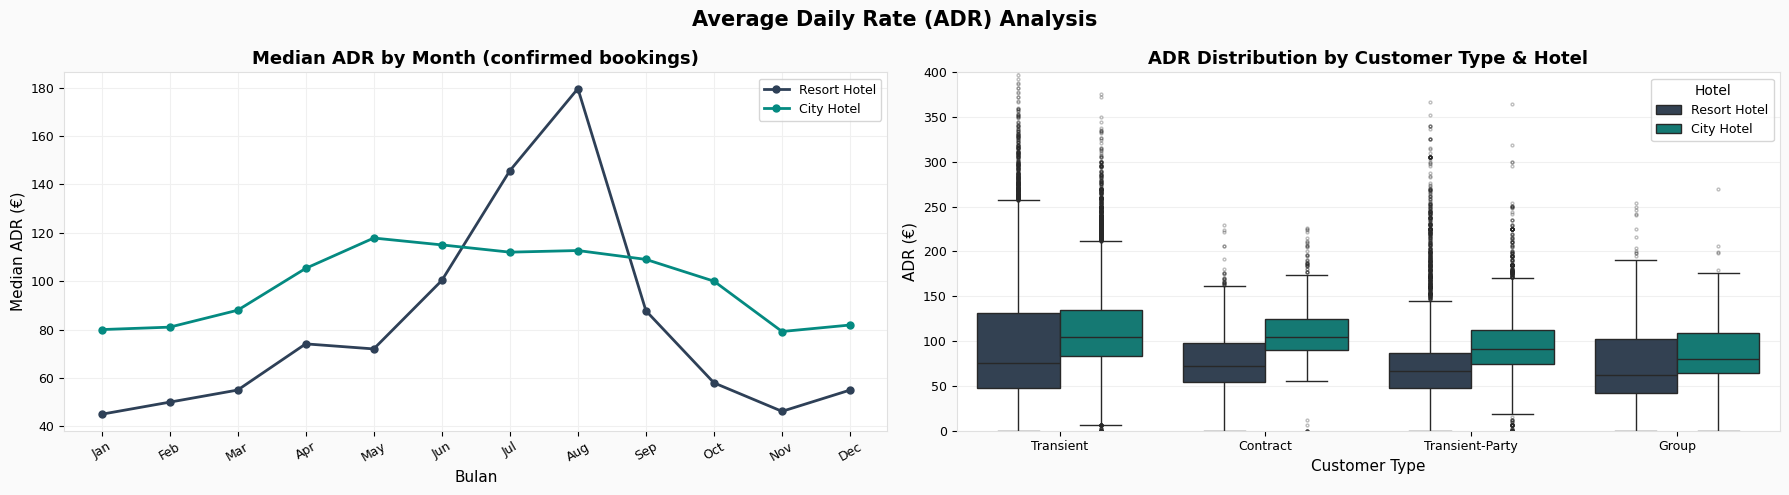

In [ ]:
# ============================================================================
# 3 Analisis ADR dan Pola Musiman
# ============================================================================
df_conf = df[df['is_canceled'] == 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Average Daily Rate (ADR) Analysis')

# Tren median ADR per bulan untuk setiap hotel
hotel_month = df_conf.copy()
hotel_month['month_num_val'] = hotel_month['month_num'].cat.codes + 1

for hotel, color in zip(df_conf['hotel'].unique(), ['#2E4057', '#048A81']):
    sub = hotel_month[hotel_month['hotel'] == hotel] \
        .groupby('month_num_val')['adr'].median()
    axes[0].plot(
        sub.index,
        sub.values,
        marker='o',
        linewidth=2,
        color=color,
        label=hotel,
        markersize=5
    )

axes[0].set_title('Median ADR by Month (confirmed bookings)')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Median ADR (€)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    rotation=30
)
axes[0].legend()

# Distribusi ADR berdasarkan customer type dan hotel
sns.boxplot(
    data=df_conf,
    x='customer_type',
    y='adr',
    hue='hotel',
    palette=['#2E4057', '#048A81'],
    ax=axes[1],
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
axes[1].set_title('ADR Distribution by Customer Type & Hotel')
axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('ADR (€)')
axes[1].set_ylim(0, 400)
axes[1].legend(title='Hotel')

plt.tight_layout()
plt.savefig('adr_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Hasil menunjukkan bahwa harga kamar cenderung meningkat pada periode tertentu, terutama saat permintaan tinggi. Selain itu, terdapat perbedaan distribusi harga antara jenis pelanggan dan hotel, yang menunjukkan adanya segmentasi pasar dalam penentuan harga.

#### **4. Analisis Geografis**
---

Analisis ini digunakan untuk melihat kontribusi masing-masing negara terhadap revenue hotel, serta hubungan antara jumlah booking, harga rata-rata, dan tingkat pembatalan.

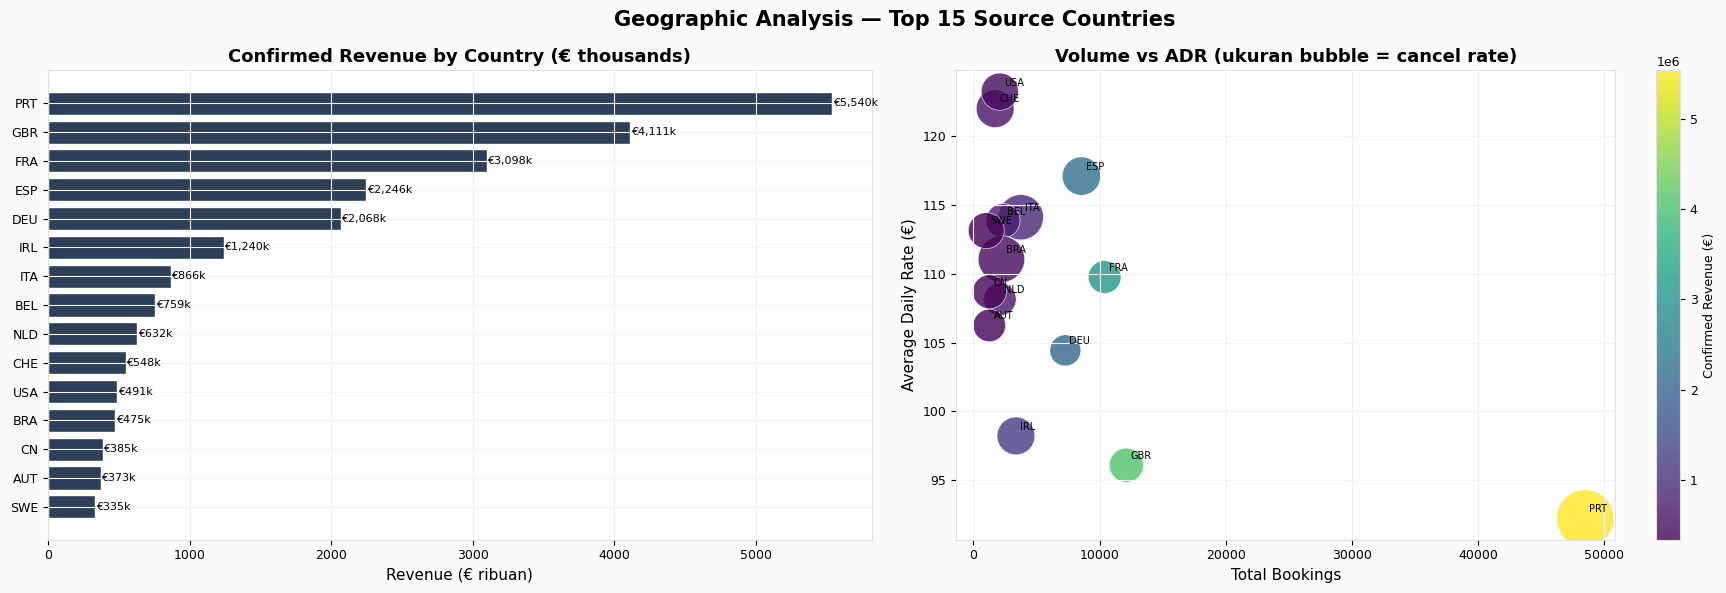

In [ ]:
# ============================================================================
# 4 Analisis Geografis: Revenue dan Volume Booking
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Geographic Analysis — Top 15 Source Countries')

# Grafik batang revenue berdasarkan negara
top_rev = df_geo.sort_values('confirmed_revenue', ascending=True)
bars = axes[0].barh(
    top_rev['country'],
    top_rev['confirmed_revenue'] / 1e3,
    color=PALETTE[0],
    edgecolor='white'
)
axes[0].set_title('Confirmed Revenue by Country (€ thousands)')
axes[0].set_xlabel('Revenue (€ ribuan)')

for bar, val in zip(bars, top_rev['confirmed_revenue'] / 1e3):
    axes[0].text(
        val + 5,
        bar.get_y() + bar.get_height() / 2,
        f'€{val:,.0f}k',
        va='center',
        fontsize=8
    )

# Scatter plot: volume booking vs ADR vs cancel rate
sc = axes[1].scatter(
    df_geo['bookings'],
    df_geo['avg_adr'],
    s=df_geo['cancel_rate_pct'] * 30,
    c=df_geo['confirmed_revenue'],
    cmap='viridis',
    alpha=0.8,
    edgecolors='white',
    linewidth=0.5
)

cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label('Confirmed Revenue (€)', fontsize=9)

for _, row in df_geo.iterrows():
    axes[1].annotate(
        row['country'],
        (row['bookings'], row['avg_adr']),
        fontsize=7,
        ha='left',
        va='bottom',
        xytext=(3, 3),
        textcoords='offset points'
    )

axes[1].set_title('Volume vs ADR (ukuran bubble = cancel rate)')
axes[1].set_xlabel('Total Bookings')
axes[1].set_ylabel('Average Daily Rate (€)')

plt.tight_layout()
plt.savefig('geo_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Beberapa negara memberikan kontribusi revenue yang lebih besar dibandingkan yang lain. Selain itu, terdapat perbedaan karakteristik antar negara, di mana ada negara dengan volume booking tinggi namun tingkat pembatalan juga tinggi, serta negara dengan nilai transaksi lebih besar.

#### **5. Analisis Segmentasi Pelanggan**
---

Analisis ini bertujuan untuk memahami performa masing-masing segmen pelanggan berdasarkan:

- revenue
- cancellation rate
- tingkat engagement (special request)

Visualisasi dalam bentuk heatmap digunakan untuk membandingkan performa antar segmen.

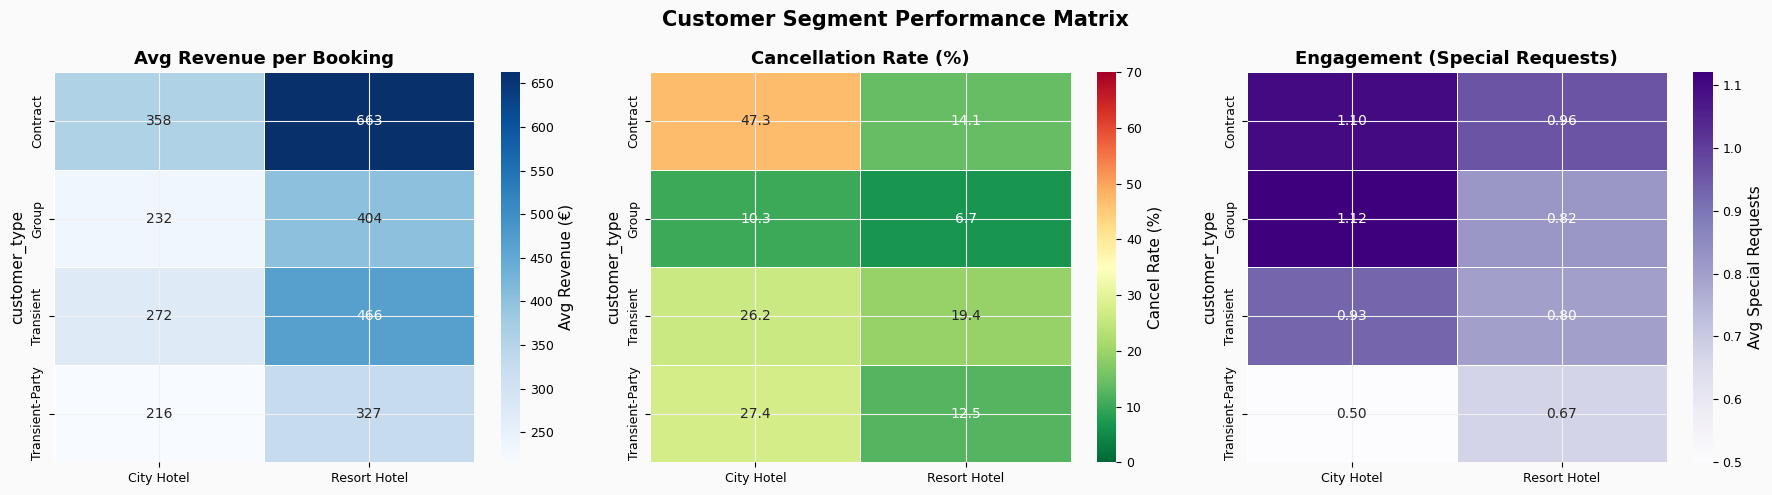

In [ ]:
# ============================================================================
# 5 Matriks Performa Segmen Pelanggan
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer Segment Performance Matrix')

# Heatmap rata-rata revenue per booking
piv_rev = df_seg.pivot_table(
    values='avg_revenue',
    index='customer_type',
    columns='hotel_name',
    aggfunc='mean'
).round(2)

sns.heatmap(
    piv_rev,
    ax=axes[0],
    cmap='Blues',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Avg Revenue (€)'}
)
axes[0].set_title('Avg Revenue per Booking')
axes[0].set_xlabel('')

# Heatmap cancellation rate
piv_cancel = df_seg.pivot_table(
    values='cancel_rate_pct',
    index='customer_type',
    columns='hotel_name',
    aggfunc='mean'
).round(1)

sns.heatmap(
    piv_cancel,
    ax=axes[1],
    cmap='RdYlGn_r',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    vmin=0,
    vmax=70,
    cbar_kws={'label': 'Cancel Rate (%)'}
)
axes[1].set_title('Cancellation Rate (%)')
axes[1].set_xlabel('')

# Heatmap special request sebagai indikator engagement
piv_req = df_seg.pivot_table(
    values='avg_special_req',
    index='customer_type',
    columns='hotel_name',
    aggfunc='mean'
).round(2)

sns.heatmap(
    piv_req,
    ax=axes[2],
    cmap='Purples',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Avg Special Requests'}
)
axes[2].set_title('Engagement (Special Requests)')
axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig('segment_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Terlihat bahwa beberapa segmen pelanggan memiliki kontribusi revenue yang lebih tinggi dibandingkan yang lain. Selain itu, terdapat perbedaan tingkat pembatalan dan engagement antar segmen, yang menunjukkan adanya variasi perilaku pelanggan. Hal ini dapat digunakan untuk menentukan target pasar yang lebih optimal.

---
## **── .✦ Strategic Business Insights & Recommendations**
---

Pada tahap ini dilakukan perumusan insight bisnis dan rekomendasi strategis berdasarkan hasil analisis sebelumnya, yaitu OLAP queries, KPI summary, dan deep dive analysis.

Insight yang dihasilkan tidak hanya menggambarkan kondisi data, tetapi juga memberikan interpretasi bisnis serta tindakan yang dapat dilakukan untuk meningkatkan performa hotel.

In [ ]:
# ============================================================================
# Perhitungan data pendukung untuk insight bisnis
# ============================================================================

# Cancellation rate berdasarkan jenis deposit
cancel_by_deposit = pd.read_sql('''
    SELECT m.deposit_type,
           ROUND(100.0*SUM(f.is_canceled)/COUNT(*),1) AS cancel_rate
    FROM fact_booking f
    JOIN dim_market m ON f.market_key = m.market_key
    GROUP BY m.deposit_type
''', conn)

# Perbandingan pelanggan baru vs pelanggan lama
repeated_rev = pd.read_sql('''
    SELECT c.is_repeated_guest,
           ROUND(AVG(f.adr),2)          AS avg_adr,
           ROUND(AVG(f.total_nights),2) AS avg_nights,
           COUNT(*)                     AS bookings
    FROM fact_booking f
    JOIN dim_customer c ON f.customer_key = c.customer_key
    WHERE f.is_canceled = 0
    GROUP BY c.is_repeated_guest
''', conn)

# Bulan dengan revenue tertinggi
peak_months = pd.read_sql('''
    SELECT d.month_name, d.month_num,
           SUM(CASE WHEN f.is_canceled=0 THEN f.total_revenue ELSE 0 END) AS rev
    FROM fact_booking f
    JOIN dim_date d ON f.date_key = d.date_key
    GROUP BY d.month_name, d.month_num
    ORDER BY rev DESC
    LIMIT 3
''', conn)

# ============================================================================
# Menampilkan insight bisnis
# ============================================================================
print("\n" + "═"*60)
print("  STRATEGIC BUSINESS INSIGHTS — HOTEL PORTFOLIO 2015–2017")
print("═"*60)

print(f"""
┌─ INSIGHT 1: Revenue & Scale
│  Total confirmed revenue: €{kpi['total_confirmed_revenue']/1e6:.2f}M
│  Total booking terkonfirmasi: {int(kpi['confirmed_bookings']):,}
│
│  → City Hotel memiliki volume booking lebih tinggi,
│    sedangkan Resort Hotel memiliki harga (ADR) lebih premium.

┌─ INSIGHT 2: Cancellation Risk
│  Tingkat pembatalan: {kpi['overall_cancel_rate']:.1f}%
│  Faktor deposit:""")

for _, row in cancel_by_deposit.iterrows():
    print(f'│    {row["deposit_type"]:<25} → {row["cancel_rate"]:>5.1f}%')

print("""
│  → Deposit non-refundable terbukti menurunkan pembatalan.
│    Disarankan menerapkan kebijakan deposit bertingkat.

┌─ INSIGHT 3: Loyal Customer
│  Perbandingan pelanggan:""")

for _, row in repeated_rev.iterrows():
    label = 'Returning guest' if row['is_repeated_guest'] else 'New guest'
    print(f'│    {label:<15} → ADR €{row["avg_adr"]:>7.2f} | {row["avg_nights"]:.1f} nights')

print("""
│  → Pelanggan lama cenderung menginap lebih lama.
│    Disarankan meningkatkan program loyalitas.

┌─ INSIGHT 4: Peak Season
│  Bulan dengan revenue tertinggi:""")

for _, row in peak_months.iterrows():
    print(f'│    {row["month_name"]:<12} → €{row["rev"]/1e3:>8,.1f}k')

print("""
│  → Terjadi peak season di pertengahan tahun.
│    Disarankan optimasi harga dan kapasitas.

┌─ INSIGHT 5: Channel Strategy
│  Channel booking berpengaruh terhadap pembatalan.
│
│  → Direct booking memiliki risiko lebih rendah dibanding OTA.
│    Disarankan meningkatkan penggunaan direct channel.

└─ REKOMENDASI
   [1] Terapkan deposit non-refundable untuk booking jauh hari
   [2] Tingkatkan program loyalitas pelanggan
   [3] Optimasi harga saat peak season
   [4] Tingkatkan direct booking channel
""")

print("═"*60)


════════════════════════════════════════════════════════════
  STRATEGIC BUSINESS INSIGHTS — HOTEL PORTFOLIO 2015–2017
════════════════════════════════════════════════════════════

┌─ INSIGHT 1: Revenue & Scale
│  Total confirmed revenue: €25.99M
│  Total booking terkonfirmasi: 75,010
│
│  → City Hotel memiliki volume booking lebih tinggi,
│    sedangkan Resort Hotel memiliki harga (ADR) lebih premium.

┌─ INSIGHT 2: Cancellation Risk
│  Tingkat pembatalan: 37.1%
│  Faktor deposit:
│    No Deposit                →  28.4%
│    Non Refund                →  99.4%
│    Refundable                →  22.2%

│  → Deposit non-refundable terbukti menurunkan pembatalan.
│    Disarankan menerapkan kebijakan deposit bertingkat.

┌─ INSIGHT 3: Loyal Customer
│  Perbandingan pelanggan:
│    New guest       → ADR € 101.79 | 3.5 nights
│    Returning guest → ADR €  63.91 | 1.9 nights

│  → Pelanggan lama cenderung menginap lebih lama.
│    Disarankan meningkatkan program loyalitas.

┌─ INSIGHT 4: Peak

Berdasarkan analisis yang dilakukan, diperoleh beberapa insight penting terkait performa bisnis hotel. Insight tersebut mencakup faktor-faktor yang memengaruhi revenue, tingkat pembatalan booking, perilaku pelanggan, serta pola musiman.

Selain itu, diberikan beberapa rekomendasi strategis yang dapat diterapkan untuk meningkatkan performa bisnis, seperti pengaturan kebijakan deposit, penguatan program loyalitas pelanggan, serta optimalisasi strategi harga dan channel distribusi.

---
## **── .✦ Metadata Repository**
---



Metadata repository digunakan untuk menyimpan informasi terkait struktur data warehouse, termasuk pemetaan antara data sumber (source) dengan tabel pada data warehouse.

Metadata ini mencakup:
- nama tabel sumber
- nama field sumber
- tabel tujuan di data warehouse
- field tujuan
- jenis transformasi yang dilakukan
- tipe data

Tujuan dari metadata ini adalah untuk memberikan dokumentasi yang jelas mengenai proses ETL, sehingga memudahkan pemahaman, maintenance, dan pengembangan sistem di masa mendatang.

In [ ]:
# ── Simpan metadata ke tabel terpisah di Data Warehouse ─────────────────────
metadata = pd.DataFrame([
    # (source_table, source_field, dw_table, dw_field, transformation, data_type)
    ('hotel_bookings','hotel',                    'dim_hotel',    'hotel_name',          'direct map',                       'TEXT'),
    ('hotel_bookings','arrival_date_*',           'dim_date',     'date_key',            'concat year+month+day → YYYYMMDD', 'INTEGER'),
    ('hotel_bookings','customer_type',            'dim_customer', 'customer_type',       'direct map',                       'TEXT'),
    ('hotel_bookings','country',                  'dim_customer', 'country',             'fillna → "Unknown"',               'TEXT'),
    ('hotel_bookings','is_repeated_guest',        'dim_customer', 'is_repeated_guest',   'direct map (0/1)',                 'INTEGER'),
    ('hotel_bookings','children+babies',          'dim_customer', 'is_family',           'derived: children>0 OR babies>0',  'INTEGER'),
    ('hotel_bookings','market_segment',           'dim_market',   'market_segment',      'direct map',                       'TEXT'),
    ('hotel_bookings','distribution_channel',     'dim_market',   'distribution_channel','direct map',                       'TEXT'),
    ('hotel_bookings','deposit_type',             'dim_market',   'deposit_type',        'direct map',                       'TEXT'),
    ('hotel_bookings','reserved_room_type',       'dim_room',     'reserved_room_type',  'direct map',                       'TEXT'),
    ('hotel_bookings','assigned_room_type',       'dim_room',     'assigned_room_type',  'direct map',                       'TEXT'),
    ('hotel_bookings','meal',                     'dim_room',     'meal',                'direct map',                       'TEXT'),
    ('hotel_bookings','adr',                      'fact_booking', 'adr',                 'filter adr>=0',                    'REAL'),
    ('hotel_bookings','adr*total_nights',         'fact_booking', 'total_revenue',       'derived: adr × total_nights',      'REAL'),
    ('hotel_bookings','stays_weekend+stays_week', 'fact_booking', 'total_nights',        'derived: sum of night columns',    'INTEGER'),
    ('hotel_bookings','adults+children+babies',   'fact_booking', 'total_guests',        'derived: sum of guest columns',    'INTEGER'),
    ('hotel_bookings','reserved_room≠assigned',   'fact_booking', 'room_upgraded',       'derived flag (0/1)',               'INTEGER'),
], columns=['source_table','source_field','dw_table','dw_field','transformation','data_type'])

# Simpan ke database
metadata.to_sql('tb_metadata', conn, if_exists='replace', index=False)

print('── Mapping ETL (Metadata Repository) ──────────────────────────')
print(metadata.to_string(index=False))
print(f'\nMetadata berhasil disimpan ke tb_metadata ({len(metadata)} mapping)')

── Mapping ETL (Metadata Repository) ──────────────────────────
  source_table             source_field     dw_table             dw_field                   transformation data_type
hotel_bookings                    hotel    dim_hotel           hotel_name                       direct map      TEXT
hotel_bookings           arrival_date_*     dim_date             date_key concat year+month+day → YYYYMMDD   INTEGER
hotel_bookings            customer_type dim_customer        customer_type                       direct map      TEXT
hotel_bookings                  country dim_customer              country               fillna → "Unknown"      TEXT
hotel_bookings        is_repeated_guest dim_customer    is_repeated_guest                 direct map (0/1)   INTEGER
hotel_bookings          children+babies dim_customer            is_family  derived: children>0 OR babies>0   INTEGER
hotel_bookings           market_segment   dim_market       market_segment                       direct map      TEXT


Metadata repository berhasil dibuat dan disimpan ke dalam tabel `tb_metadata` pada data warehouse.

Tabel ini berisi informasi mapping antara data sumber dengan struktur data warehouse, termasuk transformasi yang dilakukan pada setiap field.

Dengan adanya metadata ini, proses ETL menjadi lebih terdokumentasi dengan baik dan memudahkan dalam proses audit, debugging, maupun pengembangan sistem di masa depan.

---
## **── .✦ Export & Persist Data Warehouse**
---

Pada tahap ini, data warehouse yang sebelumnya dijalankan secara in-memory disimpan ke dalam file database SQLite.

Tujuan dari proses ini adalah:
- menyimpan hasil data warehouse secara permanen
- memungkinkan penggunaan data untuk kebutuhan reporting atau visualisasi di tools lain
- mempermudah distribusi dan reuse data

File database yang dihasilkan dapat digunakan kembali tanpa perlu menjalankan ulang proses ETL.

In [ ]:
import shutil
import os

# Simpan Data Warehouse ke file
DB_PATH = 'hotel_dw.db'
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

dest_conn = sqlite3.connect(DB_PATH)
for line in conn.iterdump():
    if line not in ('BEGIN;', 'COMMIT;'):
        try:
            dest_conn.execute(line)
        except Exception:
            pass
dest_conn.commit()
dest_conn.close()

import os
size_mb = os.path.getsize(DB_PATH) / 1e6
print(f'✅ Data Warehouse berhasil disimpan → {DB_PATH} ({size_mb:.1f} MB)')

# Download file (khusus Colab)
try:
    from google.colab import files
    files.download(DB_PATH)
    print('📥 Download dimulai.')
except ImportError:
    print('(Tidak dijalankan di Colab — file tersimpan secara lokal)')

print()
print('── Ringkasan Tabel Data Warehouse ─────────────────────────────')
check_conn = sqlite3.connect(DB_PATH)
all_tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name",
    check_conn
)
for tbl in all_tables['name']:
    n = pd.read_sql(f'SELECT COUNT(*) as n FROM "{tbl}"', check_conn).iloc[0,0]
    print(f'  {tbl:<25} {n:>9,} baris')
check_conn.close()
print('\n🎉 Selesai. Data Warehouse siap digunakan untuk reporting!')

✅ Data Warehouse berhasil disimpan → hotel_dw.db (6.7 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Download dimulai.

── Ringkasan Tabel Data Warehouse ─────────────────────────────
  dim_customer                    649 baris
  dim_date                        793 baris
  dim_hotel                         2 baris
  dim_market                       44 baris
  dim_room                        187 baris
  fact_booking                119,209 baris
  tb_metadata                      17 baris

🎉 Selesai. Data Warehouse siap digunakan untuk reporting!


In [ ]:
# Export CSV
df.to_csv('hotel_bookings_bersih.csv', index=False)
print('Data hasil cleaning berhasil disimpan → hotel_bookings_bersih.csv')

# Download CSV
try:
    from google.colab import files
    files.download('hotel_bookings_bersih.csv')
    print('Download CSV dimulai.')
except ImportError:
    print('(Tidak dijalankan di Colab — file tersimpan secara lokal)')

Data hasil cleaning berhasil disimpan → hotel_bookings_bersih.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download CSV dimulai.


Data warehouse berhasil disimpan ke dalam file `hotel_dw.db`. File ini berisi seluruh tabel yang telah dibuat sebelumnya, yaitu tabel dimensi, tabel fakta, serta metadata.

Selain itu, dilakukan verifikasi untuk memastikan bahwa seluruh tabel telah tersimpan dengan benar beserta jumlah datanya.

Dengan adanya file ini, data warehouse dapat digunakan kembali untuk keperluan analisis, visualisasi, maupun integrasi dengan tools Business Intelligence seperti Power BI atau Tableau.

---
## **── .✦ Quick Reference — Query OLAP Tambahan**
---

Bagian ini berisi beberapa contoh query tambahan yang dapat digunakan untuk eksplorasi data secara mandiri.

Query-query ini tidak termasuk dalam analisis utama, namun dapat membantu dalam memahami data lebih lanjut, seperti analisis pertumbuhan revenue, identifikasi booking dengan nilai tertinggi, serta kontribusi channel distribusi.

Query ini dapat digunakan kembali untuk kebutuhan analisis lanjutan atau pengembangan dashboard.
```sql
-- Revenue YoY growth per hotel
SELECT h.hotel_name, d.year,
       SUM(f.total_revenue) AS revenue,
       LAG(SUM(f.total_revenue)) OVER (PARTITION BY h.hotel_name ORDER BY d.year) AS prev_year,
       ROUND(100.0*(SUM(f.total_revenue) - LAG(SUM(f.total_revenue)) OVER
             (PARTITION BY h.hotel_name ORDER BY d.year)) /
             LAG(SUM(f.total_revenue)) OVER (PARTITION BY h.hotel_name ORDER BY d.year), 1) AS yoy_pct
FROM fact_booking f
JOIN dim_hotel h ON f.hotel_key = h.hotel_key
JOIN dim_date  d ON f.date_key  = d.date_key
WHERE f.is_canceled = 0
GROUP BY h.hotel_name, d.year;

-- Top 10 highest-value non-canceled bookings
SELECT f.booking_id, h.hotel_name, c.country, c.customer_type,
       f.adr, f.total_nights, f.total_revenue
FROM fact_booking f
JOIN dim_hotel    h ON f.hotel_key    = h.hotel_key
JOIN dim_customer c ON f.customer_key = c.customer_key
WHERE f.is_canceled = 0
ORDER BY f.total_revenue DESC
LIMIT 10;

-- Channel mix and revenue contribution
SELECT m.distribution_channel,
       COUNT(*) AS bookings,
       ROUND(100.0*COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS volume_share_pct,
       ROUND(SUM(CASE WHEN f.is_canceled=0 THEN f.total_revenue ELSE 0 END)) AS revenue,
       ROUND(100.0*SUM(f.is_canceled)/COUNT(*),1) AS cancel_rate
FROM fact_booking f
JOIN dim_market m ON f.market_key = m.market_key
GROUP BY m.distribution_channel
ORDER BY revenue DESC;

---
## **── .✦ Visualisasi**
---


### **↳ Analisis Tren Revenue Hotel per Tahun**
---

Analisis ini bertujuan untuk melihat perkembangan revenue hotel dari tahun ke tahun berdasarkan jenis hotel. Data yang digunakan adalah confirmed revenue, sehingga mencerminkan pendapatan yang benar-benar terealisasi.

Visualisasi ini membantu dalam memahami pertumbuhan bisnis serta membandingkan performa antar hotel.

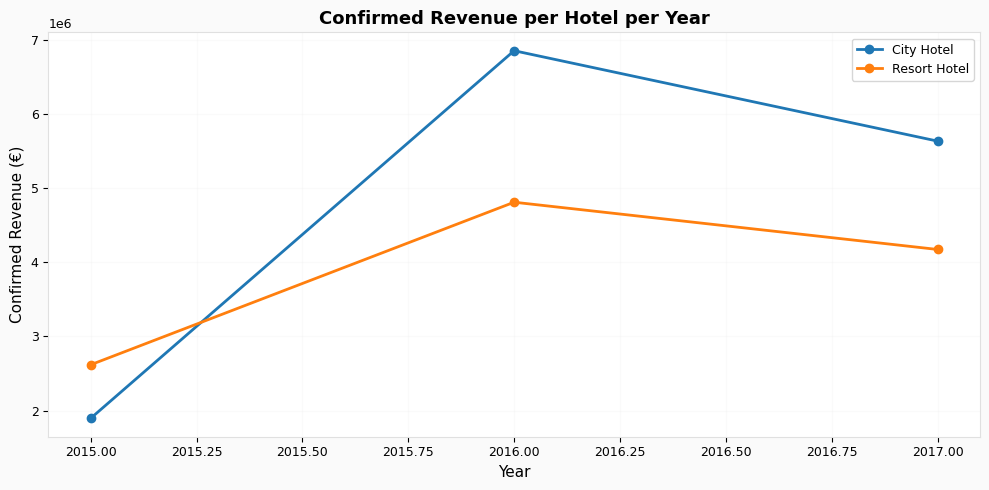

In [ ]:
# ============================================================================
# Analisis Tren Revenue per Tahun
# ============================================================================

rev_year = (
    df_rev.groupby(['hotel_name', 'year'], as_index=False)['confirmed_revenue']
    .sum()
)

plt.figure(figsize=(10, 5))

for hotel in rev_year['hotel_name'].unique():
    temp = rev_year[rev_year['hotel_name'] == hotel]
    plt.plot(
        temp['year'],
        temp['confirmed_revenue'],
        marker='o',
        linewidth=2,
        label=hotel
    )

plt.title('Confirmed Revenue per Hotel per Year')
plt.xlabel('Year')
plt.ylabel('Confirmed Revenue (€)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Berdasarkan visualisasi, terlihat bahwa revenue hotel mengalami perubahan dari tahun ke tahun. Terdapat tren peningkatan pada periode tertentu yang menunjukkan adanya pertumbuhan bisnis.

Selain itu, perbandingan antar hotel menunjukkan bahwa terdapat perbedaan performa revenue, di mana salah satu hotel cenderung menghasilkan pendapatan lebih tinggi dibandingkan yang lain. Hal ini dapat dipengaruhi oleh perbedaan segmentasi pasar, harga kamar, maupun tingkat okupansi.

Analisis ini dapat digunakan untuk mengevaluasi performa bisnis hotel secara tahunan serta sebagai dasar dalam perencanaan strategi bisnis di masa mendatang.

### **↳ Analisis Tren Revenue Hotel per Bulan**
---

Analisis ini bertujuan untuk melihat pola perubahan revenue hotel berdasarkan bulan. Dengan analisis ini, dapat diketahui adanya pola musiman (seasonality) dalam pemesanan hotel.

Visualisasi ini membantu dalam mengidentifikasi bulan dengan performa revenue tertinggi maupun terendah.

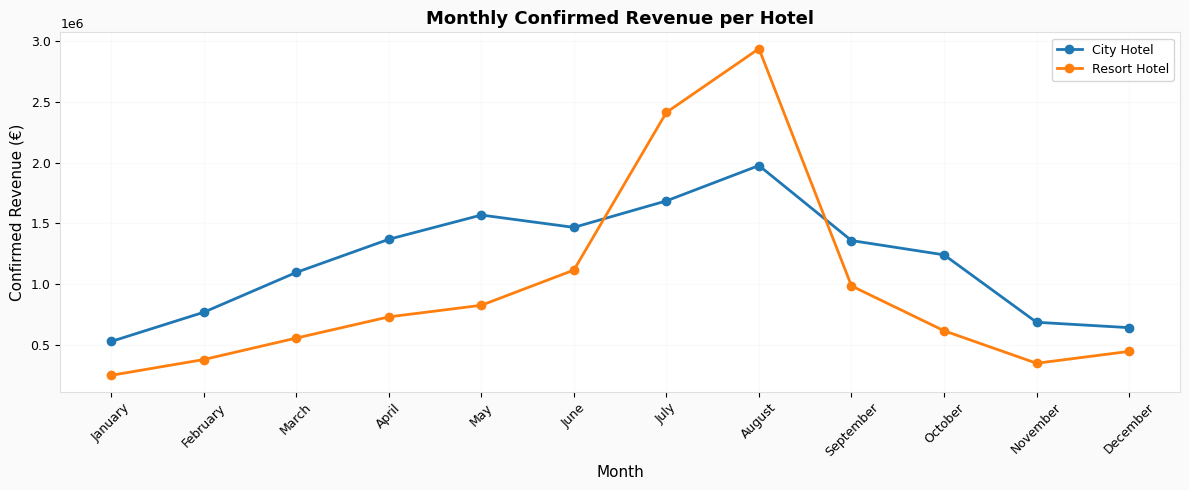

In [ ]:
# ============================================================================
# Analisis Tren Revenue Bulanan
# ============================================================================

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

rev_month = (
    df_rev.groupby(['hotel_name', 'month_name', 'month_num'], as_index=False)['confirmed_revenue']
    .sum()
    .sort_values('month_num')
)

plt.figure(figsize=(12, 5))

for hotel in rev_month['hotel_name'].unique():
    temp = rev_month[rev_month['hotel_name'] == hotel].sort_values('month_num')
    plt.plot(
        temp['month_name'],
        temp['confirmed_revenue'],
        marker='o',
        linewidth=2,
        label=hotel
    )

plt.title('Monthly Confirmed Revenue per Hotel')
plt.xlabel('Month')
plt.ylabel('Confirmed Revenue (€)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Berdasarkan visualisasi, terlihat bahwa revenue hotel mengalami fluktuasi sepanjang bulan dalam satu tahun. Terdapat bulan-bulan tertentu yang menunjukkan peningkatan revenue yang signifikan dibandingkan bulan lainnya.

Pola ini mengindikasikan adanya **seasonality**, di mana permintaan hotel meningkat pada periode tertentu, seperti musim liburan atau peak season. Sebaliknya, terdapat periode dengan revenue lebih rendah yang kemungkinan merupakan low season.

Selain itu, terlihat bahwa kedua jenis hotel memiliki pola yang relatif mirip, namun dengan tingkat revenue yang berbeda, yang menunjukkan adanya perbedaan strategi harga atau target pasar.

Analisis ini penting untuk membantu hotel dalam:
- menentukan strategi pricing berdasarkan musim
- mengoptimalkan promosi pada periode low season
- meningkatkan kapasitas pada periode peak season

### **↳ Distribusi Harga Booking Hotel per Malam (ADR)**
---

Analisis ini bertujuan untuk melihat distribusi harga kamar hotel per malam (Average Daily Rate / ADR) pada booking yang tidak dibatalkan.

Dengan analisis ini, dapat diketahui pola sebaran harga, rentang harga yang paling sering digunakan, serta adanya outlier pada data harga kamar.

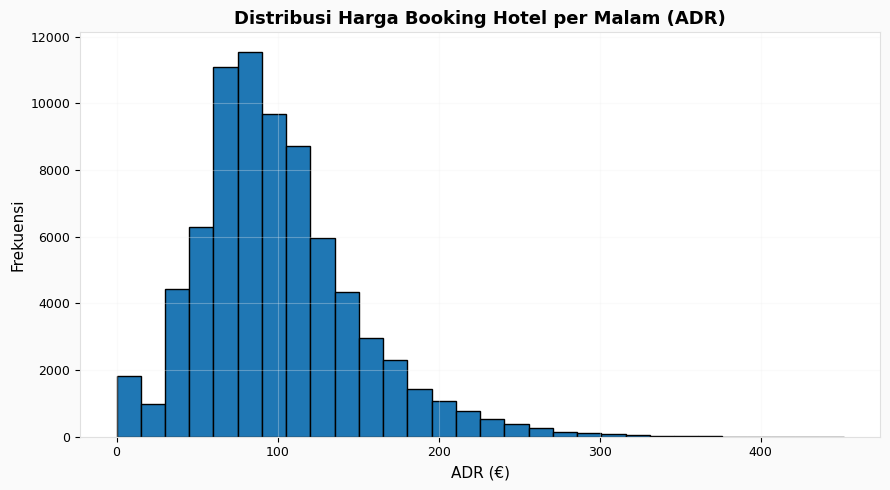

In [ ]:
# ============================================================================
# Distribusi Harga (ADR)
# ============================================================================

dist_adr = pd.read_sql("""
SELECT adr
FROM fact_booking
WHERE is_canceled = 0
  AND adr IS NOT NULL
  AND adr <= 500
""", conn)

plt.figure(figsize=(9, 5))

plt.hist(
    dist_adr['adr'],
    bins=30,
    edgecolor='black'
)

plt.title('Distribusi Harga Booking Hotel per Malam (ADR)')
plt.xlabel('ADR (€)')
plt.ylabel('Frekuensi')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Berdasarkan histogram, terlihat bahwa distribusi harga kamar (ADR) tidak merata dan cenderung terkonsentrasi pada rentang harga tertentu.

Sebagian besar booking berada pada kisaran harga menengah, sementara hanya sedikit booking yang memiliki harga sangat tinggi. Hal ini menunjukkan bahwa mayoritas pelanggan memilih harga yang lebih terjangkau.

Selain itu, terdapat beberapa nilai ekstrem (outlier) yang menunjukkan adanya kamar dengan harga premium, kemungkinan pada periode peak season atau untuk tipe kamar tertentu.

Analisis ini penting untuk:
- memahami strategi penentuan harga
- mengidentifikasi segmen pasar berdasarkan harga
- menentukan rentang harga optimal untuk meningkatkan revenue

### **↳ Hubungan Harga (ADR) dan Lama Menginap Pelanggan**
---

Analisis ini bertujuan untuk melihat hubungan antara harga kamar per malam (ADR) dengan lama menginap pelanggan (total nights).

Dengan menggunakan scatter plot, dapat diketahui apakah terdapat pola tertentu, misalnya apakah pelanggan yang menginap lebih lama cenderung mendapatkan harga yang lebih rendah atau lebih tinggi.

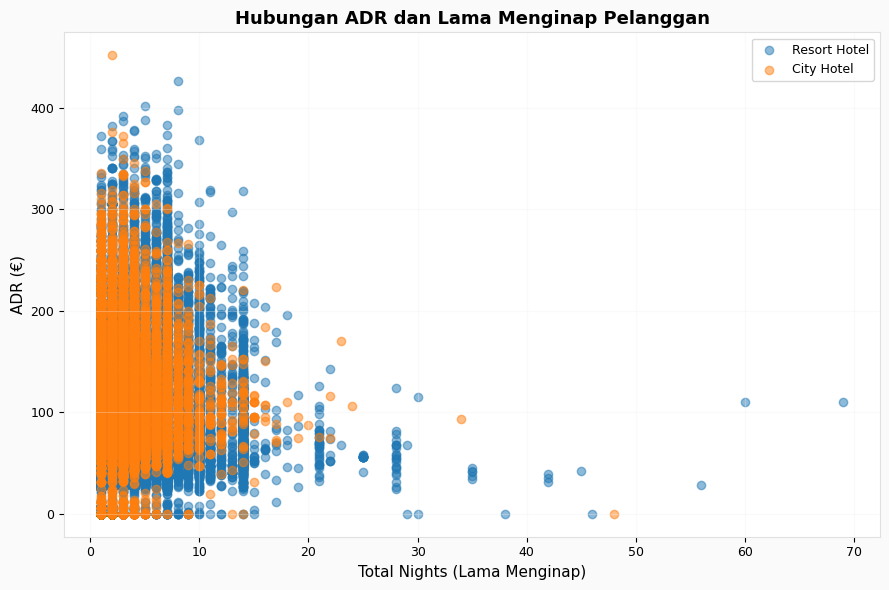

In [ ]:
# ============================================================================
# Analisis Hubungan ADR dan Lama Menginap
# ============================================================================

rel_df = pd.read_sql("""
SELECT h.hotel_name,
       f.adr,
       f.total_nights,
       f.total_revenue
FROM fact_booking f
JOIN dim_hotel h ON f.hotel_key = h.hotel_key
WHERE f.is_canceled = 0
  AND f.adr IS NOT NULL
  AND f.total_nights > 0
  AND f.adr <= 500
""", conn)

plt.figure(figsize=(9, 6))

for hotel in rel_df['hotel_name'].unique():
    temp = rel_df[rel_df['hotel_name'] == hotel]
    plt.scatter(
        temp['total_nights'],
        temp['adr'],
        alpha=0.5,
        label=hotel
    )

plt.title('Hubungan ADR dan Lama Menginap Pelanggan')
plt.xlabel('Total Nights (Lama Menginap)')
plt.ylabel('ADR (€)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Berdasarkan scatter plot, terlihat bahwa tidak terdapat hubungan linear yang sangat kuat antara lama menginap dan harga kamar (ADR). Sebaran data menunjukkan bahwa harga kamar relatif bervariasi pada berbagai lama menginap.

Namun, terdapat kecenderungan bahwa sebagian pelanggan dengan lama menginap lebih panjang memperoleh harga yang sedikit lebih rendah, yang dapat disebabkan oleh adanya diskon untuk long stay.

Selain itu, terlihat adanya variasi harga yang cukup besar pada durasi menginap yang sama, yang menunjukkan bahwa harga juga dipengaruhi oleh faktor lain seperti tipe kamar, musim, dan segmentasi pelanggan.

Analisis ini penting untuk:
- memahami strategi pricing hotel
- mengidentifikasi peluang diskon untuk long stay
- mengoptimalkan kombinasi harga dan durasi menginap untuk meningkatkan revenue